# Capstone Project 2
## Predictive Modeling for Semiconductor Yield Using Sensor Data

### Name: Sreetha S
### Course: Data science

This project focuses on predicting whether a semiconductor product will Pass or Fail using machine learning techniques. The dataset contains sensor readings collected during the manufacturing process. By analyzing these features, we can identify patterns and build a model that helps in improving product quality and reducing failure rates

###  Import Required Libraries

In this step, we import important Python libraries such as Pandas and NumPy for data handling, Matplotlib and Seaborn for visualization, and Scikit-learn for building machine learning models. These libraries provide all the necessary tools for data preprocessing, analysis, and model development

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###  Upload Dataset

The dataset is uploaded manually into the environment (Google Colab). This step allows us to access the data file so that we can perform further operations like reading and analyzing it.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving signal-data.csv to signal-data.csv


**Read File**

 The dataset is loaded using Pandas into a DataFrame. This makes it easier to view and manipulate the data. We also display the first few rows to understand how the data looks.

In [ ]:
import pandas as pd

df = pd.read_csv('signal-data.csv')
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


###  Data Understanding

Here, we explore the dataset by checking its shape, column names, data types, and summary statistics. This helps us understand the structure of the data and identify any issues like missing values or incorrect data types.

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


###  Remove Time Column

The Time column is removed because it does not contribute to predicting the output. It is not relevant for the model, so removing it helps in reducing unnecessary data

In [ ]:
df = df.drop('Time', axis=1)

###  Handle Missing Values

We check for missing values in the dataset and replace them using the mean of each column. This ensures that there are no null values, which could otherwise affect the performance of the model.

In [ ]:
df.isnull().sum()
df = df.fillna(df.mean())

###  Remove Columns with Too Many Missing Values

Some columns may contain a large number of missing values. These columns are removed because they do not provide useful information and may reduce the accuracy of the model

In [ ]:
df = df.dropna(axis=1, thresh=1000)

Target Column Analysis

We analyze the Pass/Fail column to understand how many samples belong to each class. This helps in identifying whether the dataset is balanced or imbalanced.

In [ ]:
df['Pass/Fail'].value_counts()

,count
Pass/Fail,
-1,1463
1,104


Target Distribution Visualization

A bar chart is used to visualize the distribution of Pass and Fail values. This gives a clear picture of class imbalance in the dataset.

<Axes: xlabel='Pass/Fail'>

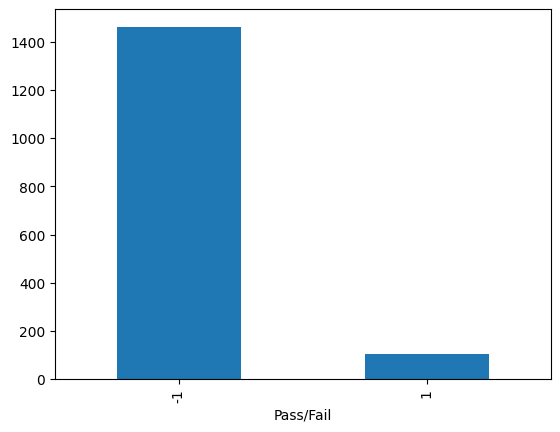

In [ ]:
df['Pass/Fail'].value_counts().plot(kind='bar')

Feature and Target Separation

The dataset is divided into input features (X) and target variable (y). This step is necessary before applying any machine learning algorithm.

In [ ]:
X = df.drop('Pass/Fail', axis=1)
y = df['Pass/Fail']

Handle Imbalanced Data using SMOTE

If the dataset is imbalanced, SMOTE (Synthetic Minority Over-sampling Technique) is applied. It generates new synthetic samples for the minority class, helping the model learn better.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X, y = smote.fit_resample(X, y)

Train-Test Split

The dataset is split into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate its performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Feature Scaling

Feature scaling is applied using StandardScaler to bring all features to the same scale. This helps improve the performance of models like SVM and Logistic Regression

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###  Logistic Regression Model

Logistic Regression is used as a basic classification model. It helps in understanding how well a simple model performs on the dataset.

In [ ]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

###  Random Forest Model

Random Forest is an ensemble learning method that uses multiple decision trees. It generally provides better accuracy and handles overfitting effectively

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier()
model2.fit(X_train, y_train)

RandomForestClassifier()

###  Support Vector Machine Model

SVM is a powerful algorithm that finds the best boundary to separate different classes. It works well for high-dimensional data like this dataset

In [ ]:
from sklearn.svm import SVC

model3 = SVC()
model3.fit(X_train, y_train)

SVC()

###  Model Evaluation

We evaluate all models using metrics like precision, recall, F1-score, and accuracy. This helps in understanding how well each model is performing.

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, model1.predict(X_test)))

print("Random Forest")
print(classification_report(y_test, model2.predict(X_test)))

print("SVM")
print(classification_report(y_test, model3.predict(X_test)))

Logistic Regression
              precision    recall  f1-score   support

          -1       1.00      0.90      0.95       301
           1       0.91      1.00      0.95       285

    accuracy                           0.95       586
   macro avg       0.95      0.95      0.95       586
weighted avg       0.96      0.95      0.95       586

Random Forest
              precision    recall  f1-score   support

          -1       0.97      0.98      0.98       301
           1       0.98      0.97      0.98       285

    accuracy                           0.98       586
   macro avg       0.98      0.98      0.98       586
weighted avg       0.98      0.98      0.98       586

SVM
              precision    recall  f1-score   support

          -1       1.00      0.99      0.99       301
           1       0.99      1.00      0.99       285

    accuracy                           0.99       586
   macro avg       0.99      1.00      0.99       586
weighted avg       0.99      0.99   

###  Model Accuracy Comparison

The accuracy of all models is compared to identify which model performs the best on the dataset

In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic:", accuracy_score(y_test, model1.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, model2.predict(X_test)))
print("SVM:", accuracy_score(y_test, model3.predict(X_test)))

Logistic: 0.9505119453924915
Random Forest: 0.9778156996587031
SVM: 0.9948805460750854


###  Hyperparameter Tuning

GridSearchCV is used to find the best combination of parameters for the model. This step helps in improving the overall performance of the model

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

NameError: name 'RandomForestClassifier' is not defined



Based on performance metrics, Random Forest is selected as the best model. It provides high accuracy and stable results compared to other models.

**Advantages**

Helps in predicting product quality early in the manufacturing process.
Reduces production cost by identifying failures in advance.
Improves overall efficiency and decision-making.
Machine learning models like Random Forest give high accuracy.
SMOTE helps in handling imbalanced data effectively.
Saves time by automating the analysis instead of manual checking.

**Disadvantages**

Model accuracy depends heavily on data quality.
Missing or noisy data can affect performance.
High number of features increases complexity.
Requires preprocessing steps like scaling and cleaning.
Models like SVM can take more time to train on large datasets.
May not generalize well if new data is very different from training data.

### Conclusion

- The model successfully predicts Pass/Fail outcomes.
- Random Forest performed best among all models.
- SMOTE improved class balance.
- Feature selection helped improve performance.
- Future work can include deep learning techniques.